In [1]:
# using Pkg
# Pkg.activate("/home/jek354/research/ML-signproblem")
# Pkg.update()

using Lattices
using LinearAlgebra
using Combinatorics
using SparseArrays
using Plots
import Graphs
using LaTeXStrings
using Statistics
using Random
using Zygote
using Optimization, OptimizationOptimisers
using JSON
using OptimizationOptimJL
using JLD2
using ExponentialUtilities


include("ed_objects.jl")
include("ed_functions.jl")
include("ed_optimization.jl")
include("utility_functions.jl")

merge_jld2_folder

In [7]:
electrons = (4,5)
folder = "data/N=$(electrons)_3x3"
# folder="data/tmp"

e_metadata = load_saved_dict(joinpath(folder, "meta_data_and_E.jld2"))
U_values = e_metadata["meta_data"]["U_values"]
dim = [parse(Int, x) for x in split(e_metadata["meta_data"]["sites"], "x")]
shared_data = load_saved_dict(joinpath(folder, "unitary_map_energy_symmetry=false_N=$(electrons)_shared.jld2"))
coefficient_data = []
interaction_data = []
loss1 = []
loss2 = []
initial_loss = [] 
for i = 2:61#2:61
    dic = load_saved_dict(joinpath(folder, "unitary_map_energy_symmetry=false_N=$(electrons)_u_$i.jld2"))
    push!(coefficient_data, dic["coefficients"][2])
    push!(interaction_data, U_values[i])
    push!(loss1, dic["metrics"]["loss"][2])
    if length(dic["metrics"]["loss"]) > 2
        push!(loss2, dic["metrics"]["loss"][3])
    end
    push!(initial_loss, dic["metrics"]["loss"][1])
end
coefficient_data = reduce(hcat, coefficient_data);

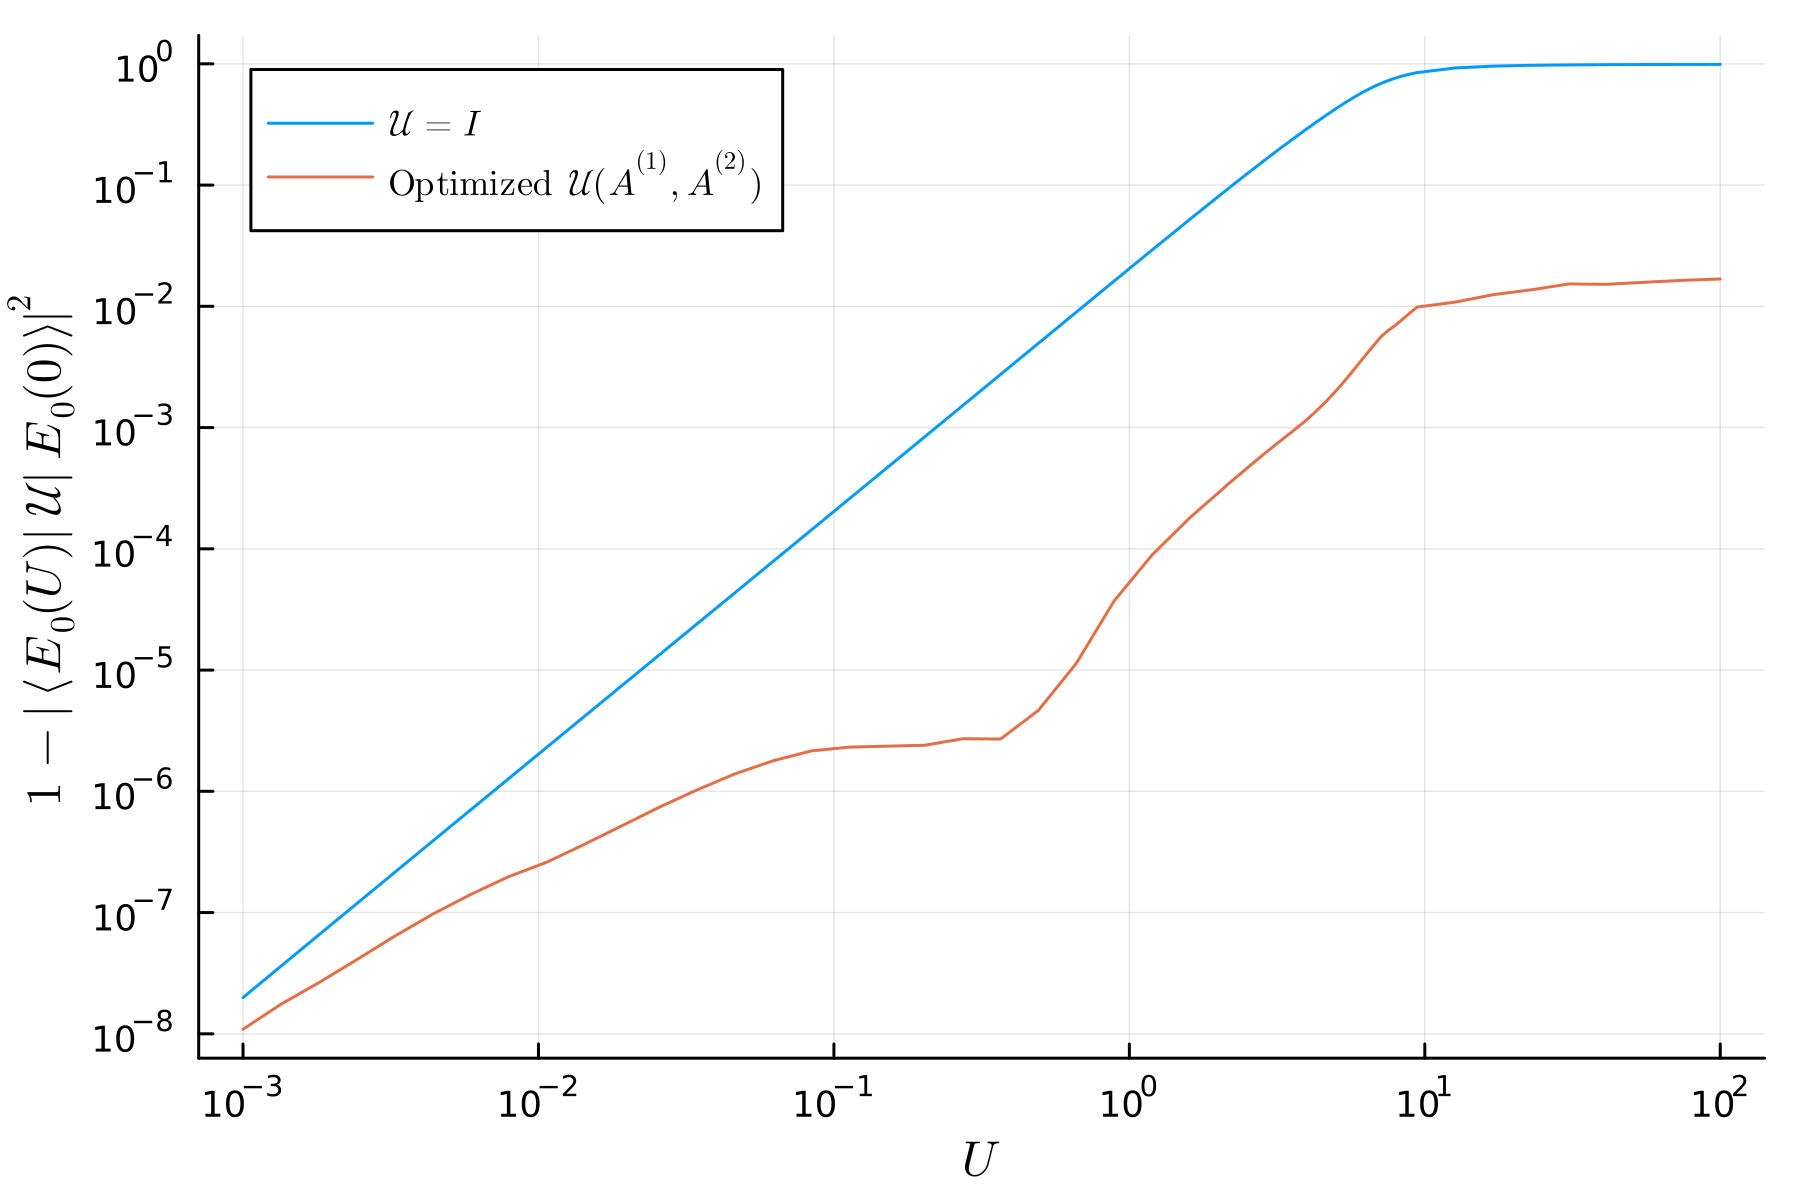

In [ ]:
p = plot(yscale=:log10, dpi=300, xscale=:log10, ylabel=L"1-|\langle E_0(U)|\mathcal{U}|E_0(0)\rangle|^2", xlabel=L"U", yticks=10.0 .^(-10:0), xticks=10.0 .^(-3:3), legend=:topleft)
plot!(p, interaction_data, initial_loss, label=L"\mathcal{U}=I")
plot!(p, interaction_data, loss1, label=L"\textrm{Optimized }\;\;\mathcal{U}(A^{(1)},A^{(2)})")
savefig(p, "loss_curve_3x3.png")
display(p)
# plot!(interaction_data, loss2, label=L"(n=2)+(n=1)")


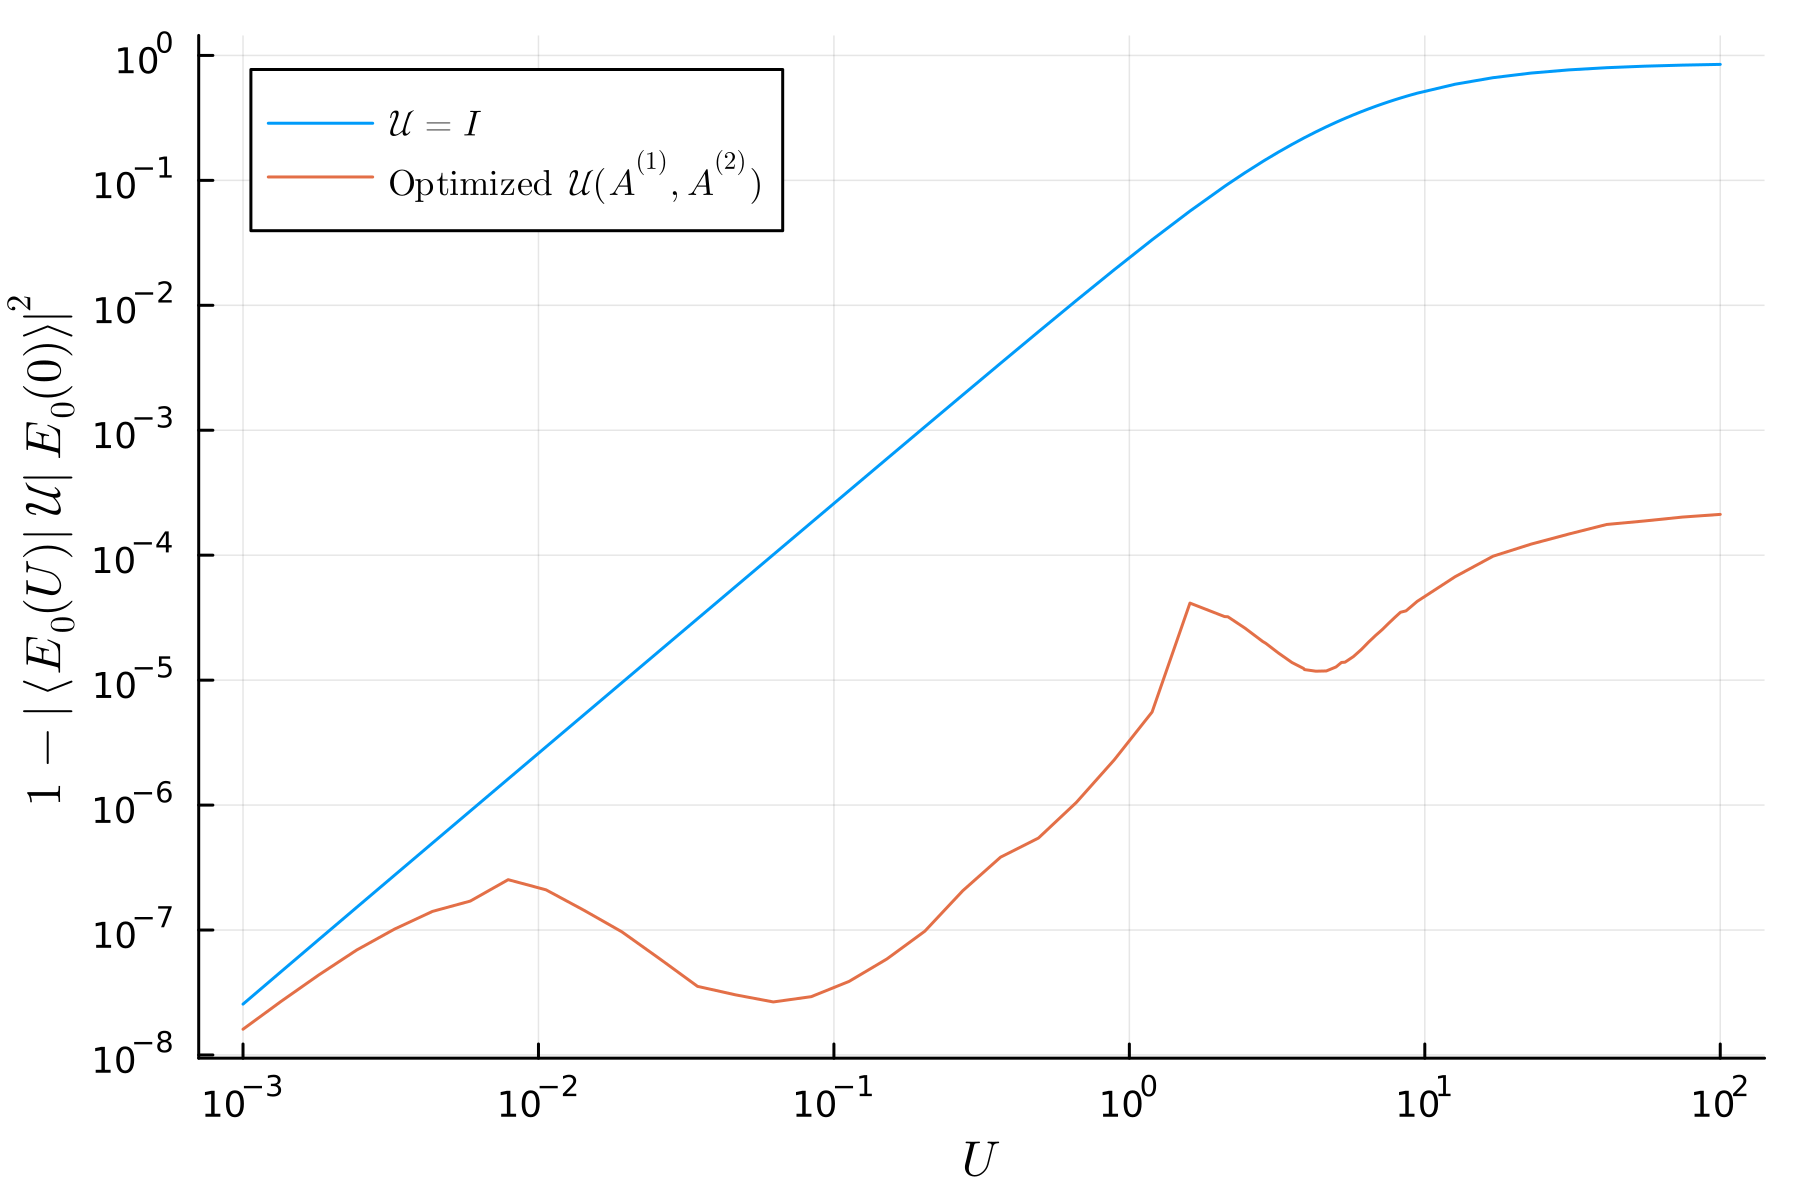

In [6]:
p = plot(yscale=:log10, dpi=300, xscale=:log10, ylabel=L"1-|\langle E_0(U)|\mathcal{U}|E_0(0)\rangle|^2", xlabel=L"U", yticks=10.0 .^(-10:0), xticks=10.0 .^(-3:3), legend=:topleft)
plot!(p, interaction_data, initial_loss, label=L"\mathcal{U}=I")
plot!(p, interaction_data, loss1, label=L"\textrm{Optimized }\;\;\mathcal{U}(A^{(1)},A^{(2)})")
savefig(p, "loss_curve_3x2.png")
display(p)
# plot!(interaction_data, loss2, label=L"(n=2)+(n=1)")


In [9]:
# u_data["coefficient_values"][2]

using Plots
using LaTeXStrings


order = 2
x = []
y = []
z = []
z1 = []
z2 = []
target_spin = 3 .-[1,1,1,1]
selected_coefficient_index = falses(length(shared_data["coefficient_labels"][2])) # to filter spins
for i in eachindex(if shared_data["coefficient_labels"][order] !== nothing shared_data["coefficient_labels"][order] else [] end)
    # k1 + k2 -> k1' + k2'
    if !all(shared_data["coefficient_labels"][2][i][term][2] == target_spin[term] for term in 1:4)
        continue
    end
    # display(shared_data["coefficient_labels"][2][i])
    s = sum(abs2, (collect((shared_data["coefficient_labels"][2][i][1][1] +  shared_data["coefficient_labels"][2][i][2][1]).coordinates) .- 2)) # (k1 + k2)^2
    t = sum(abs2, (shared_data["coefficient_labels"][2][i][1][1] -  shared_data["coefficient_labels"][2][i][1+order][1]).coordinates) # (k1 - k1')^2
    u = sum(abs2, (shared_data["coefficient_labels"][2][i][1][1] -  shared_data["coefficient_labels"][2][i][2+order][1]).coordinates) # (k1 - k2')^2
    # println("($s, $t, $u): $(u_data["coefficient_values"][2][i])")

    # push!(x, (u -t)+(rand()*2-1)*0.2)
    push!(x, s)
    push!(y, t)
    push!(z, u)
    # push!(y, s+(rand()*2-1)*0.2)
    selected_coefficient_index[i] = true

end


# scatter(x,y,z, marker_z=coefficient_data[selected_coefficient_index, 1], color=:balance,xlabel=L"s", ylabel=L"t", zlabel="u")

high_range_mask = abs.(coefficient_data[:, 50]) .> 0.2
mid_range_mask = 0.05 .< abs.(coefficient_data[:, 50]) .< 0.2
low_range_mask = abs.(coefficient_data[:, 50]) .< 0.05
# histogram(abs.(coefficient_data[selected_coefficient_index, 50]), bins=30)

for i in eachindex(selected_coefficient_index)
    if !selected_coefficient_index[i] || !high_range_mask[i] 
        continue
    end
    display(shared_data["coefficient_labels"][2][i])
end

4-element Vector{Tuple{Coordinate{2, Int64}, Int64, Symbol}}:
 (Coordinate(1, 1), 2, :create)
 (Coordinate(1, 3), 2, :create)
 (Coordinate(1, 1), 2, :annihilate)
 (Coordinate(1, 3), 2, :annihilate)

4-element Vector{Tuple{Coordinate{2, Int64}, Int64, Symbol}}:
 (Coordinate(1, 1), 2, :create)
 (Coordinate(2, 1), 2, :create)
 (Coordinate(1, 1), 2, :annihilate)
 (Coordinate(2, 1), 2, :annihilate)

4-element Vector{Tuple{Coordinate{2, Int64}, Int64, Symbol}}:
 (Coordinate(1, 1), 2, :create)
 (Coordinate(2, 3), 2, :create)
 (Coordinate(1, 2), 2, :annihilate)
 (Coordinate(2, 2), 2, :annihilate)

4-element Vector{Tuple{Coordinate{2, Int64}, Int64, Symbol}}:
 (Coordinate(1, 1), 2, :create)
 (Coordinate(2, 3), 2, :create)
 (Coordinate(3, 1), 2, :annihilate)
 (Coordinate(3, 3), 2, :annihilate)

4-element Vector{Tuple{Coordinate{2, Int64}, Int64, Symbol}}:
 (Coordinate(1, 1), 2, :create)
 (Coordinate(3, 1), 2, :create)
 (Coordinate(1, 1), 2, :annihilate)
 (Coordinate(3, 1), 2, :annihilate)

...

4-element Vector{Tuple{Coordinate{2, Int64}, Int64, Symbol}}:
 (Coordinate(1, 2), 2, :create)
 (Coordinate(3, 3), 2, :create)
 (Coordinate(2, 2), 2, :annihilate)
 (Coordinate(2, 3), 2, :annihilate)

4-element Vector{Tuple{Coordinate{2, Int64}, Int64, Symbol}}:
 (Coordinate(2, 1), 2, :create)
 (Coordinate(3, 3), 2, :create)
 (Coordinate(2, 3), 2, :annihilate)
 (Coordinate(3, 1), 2, :annihilate)

4-element Vector{Tuple{Coordinate{2, Int64}, Int64, Symbol}}:
 (Coordinate(2, 2), 2, :create)
 (Coordinate(2, 3), 2, :create)
 (Coordinate(2, 2), 2, :annihilate)
 (Coordinate(2, 3), 2, :annihilate)

4-element Vector{Tuple{Coordinate{2, Int64}, Int64, Symbol}}:
 (Coordinate(2, 2), 2, :create)
 (Coordinate(3, 3), 2, :create)
 (Coordinate(2, 3), 2, :annihilate)
 (Coordinate(3, 2), 2, :annihilate)

4-element Vector{Tuple{Coordinate{2, Int64}, Int64, Symbol}}:
 (Coordinate(3, 2), 2, :create)
 (Coordinate(3, 3), 2, :create)
 (Coordinate(3, 2), 2, :annihilate)
 (Coordinate(3, 3), 2, :annihilate)

In [ ]:
# u_data["coefficient_values"][2]

using Plots
using LaTeXStrings


order = 2
u_index = 50
spins = [[1,1,1,1], [2,2,2,2], [1,2,1,2], [2,1,2,1], [1,2,2,1], [2,1,1,2]]
y_coords = [1,1,1,1]
collected_values = zeros(length(spins), 3,3,3)
for (spin_i, target_spin) in enumerate(spins)
    kx_values = []
    selected_coefficient_index = falses(length(shared_data["coefficient_labels"][2])) # to filter spins
    for i in eachindex(if shared_data["coefficient_labels"][order] !== nothing shared_data["coefficient_labels"][order] else [] end)
        # k1 + k2 -> k1' + k2'
        # constrain that it's the target spin
        if !all(shared_data["coefficient_labels"][2][i][term][2] == target_spin[term] for term in 1:4)
            continue
        end

        # constrain ky==0 (slice)
        if !all(shared_data["coefficient_labels"][2][i][term][1].coordinates[2] == y_coords[term] for term in 1:4)
            continue
            
        end

        push!(kx_values, [])
        for j=1:4
            push!(kx_values[end], shared_data["coefficient_labels"][2][i][j][1].coordinates[1]-1)
        end

        selected_coefficient_index[i] = true

        # collect colelcted_values to plot
        _i,_j,_k,_l = kx_values[end] .+ 1
        for swap1 in [1, -1]
            for swap2 in [1, -1]
                first_two = swap1 == 1 ? [_i,_j] : [_j,_i]
                last_two = swap2 == 1 ? [_k,_l] : [_l,_k]
                if (first_two[1] == first_two[2] && swap1 == -1) || (last_two[1] == last_two[2] && swap2 == -1)
                    continue
                end
                collected_values[spin_i,first_two...,last_two[1]] = swap1*swap2*coefficient_data[i, u_index]
            end
        end 
    end


    # scatter(x,y,z, marker_z=coefficient_data[selected_coefficient_index, 1], color=:balance,xlabel=L"s", ylabel=L"t", zlabel="u")
    # println(sum(selected_coefficient_in≥dex))
    for i in eachindex(kx_values)
        tmp_ycoords = y_coords .- 1
        dd = kx_values[i][1] == kx_values[i][3] && tmp_ycoords[1] == tmp_ycoords[3] && kx_values[i][2] == kx_values[i][4] && tmp_ycoords[2] == tmp_ycoords[4]
        onsite = (kx_values[i][1] == kx_values[i][3] == kx_values[i][2] == kx_values[i][4]) && (tmp_ycoords[1]  == tmp_ycoords[2] == tmp_ycoords[3]  == tmp_ycoords[4])
            pairing = (kx_values[i][1] == kx_values[i][2] && tmp_ycoords[1] == tmp_ycoords[2]) && (kx_values[i][3] == kx_values[i][4] && tmp_ycoords[3] == tmp_ycoords[4])
        double_to_split = ((kx_values[i][1] == kx_values[i][2] && tmp_ycoords[1] == tmp_ycoords[2]) || (kx_values[i][3] == kx_values[i][4] && tmp_ycoords[3] == tmp_ycoords[4])) && !dd && !pairing
        label = begin 
            if dd 
                spin_flip = !(target_spin[1] == target_spin[3] && target_spin[2] == target_spin[4])
                "dd($(abs(kx_values[i][1] - kx_values[i][2])),$(abs(tmp_ycoords[1] - tmp_ycoords[2]))) " * (spin_flip ? "spin_flip " : "")  
            else 
                "" 
            end * 
            if onsite
                "onsite " 
            else 
                "" 
            end * 
            if pairing 
                "pairing " 
            else 
                "" 
            end * 
            if double_to_split 
                "double_to_split" 
            else 
                "" 
            end
        end
        println("$target_spin $(kx_values[i]) $(coefficient_data[selected_coefficient_index, :][i, u_index]) $(label)")
    end
end


[1, 1, 1, 1] Any[1, 2, 1, 2] -0.05569937107348609 
[1, 1, 1, 1] Any[0, 1, 0, 1] -0.05589306335632437 
[1, 1, 1, 1] Any[0, 2, 0, 2] -0.05589306345657777 
[2, 2, 2, 2] Any[0, 2, 0, 2] -0.055893285269632983 
[2, 2, 2, 2] Any[0, 1, 0, 1] -0.05589328533628812 
[2, 2, 2, 2] Any[1, 2, 1, 2] -0.05569957198686414 
[1, 2, 1, 2] Any[1, 1, 1, 1] -0.22287659962429293 pairing 
[1, 2, 1, 2] Any[0, 1, 2, 2] -0.38031087044008416 double_to_split
[1, 2, 1, 2] Any[0, 1, 0, 1] -0.33535026682595 
[1, 2, 1, 2] Any[1, 2, 1, 2] -0.3363848213106603 
[1, 2, 1, 2] Any[0, 2, 1, 1] -0.3803108681449682 double_to_split
[1, 2, 1, 2] Any[0, 0, 1, 2] -0.36964038321719106 double_to_split
[1, 2, 1, 2] Any[0, 0, 0, 0] -0.22320694662469517 pairing 
[1, 2, 1, 2] Any[0, 2, 0, 2] -0.33535026452835687 
[1, 2, 1, 2] Any[2, 2, 2, 2] -0.2228765999228592 pairing 
[2, 1, 2, 1] Any[0, 2, 0, 2] -0.3353502813376865 
[2, 1, 2, 1] Any[1, 2, 1, 2] -0.3363848239805367 
[2, 1, 2, 1] Any[0, 1, 0, 1] -0.33535027897617314 
[1, 2, 2, 1] Any[0, 

In [ ]:
using Plots.Measures: mm
p = []
for j=1:6
for i=1:3
    push!(p,heatmap(collected_values[j, :,:,i],c=:balance, yticks=[1,2,3], xticks=[1,2,3], clims=(-0.4,0.4),xlabel=L"k^x_1",ylabel=L"k^x_2", title=L"A^{(2)}_{\mathbf{k}_1\mathbf{k}_2\mathbf{k}_3\mathbf{k}_4}c^\dagger_{\mathbf{k}_1}c^\dagger_{\mathbf{k}_2}c_{\mathbf{k}_3}c_{\mathbf{k}_4},\quad k^x_3=%$i \;%$(spins[j])" ))
end
end
plot(p...,layout=(6,3),size=(1200,2000),link=:y, top_margin=0mm,bottom_margin=0mm,left_margin=0mm,right_margin=-5mm)
savefig("coefficients")

"/home/jonathon/Dropbox/programming/cornell courses/research/experimenting/ed/coefficients.png"

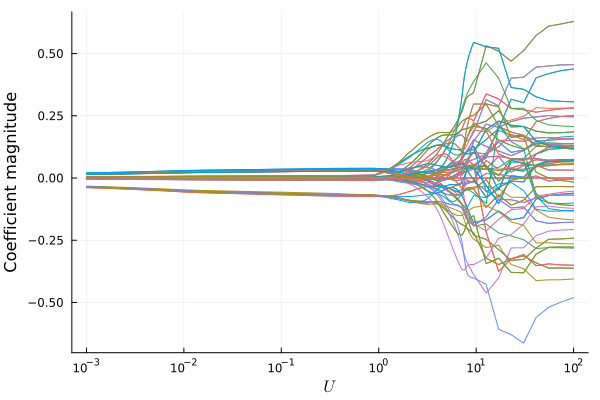

In [ ]:
p = plot(interaction_data , coefficient_data[selected_coefficient_index, :]', legend=nothing,xticks=10.0 .^(-10:10), xlabel=L"U", ylabel="Coefficient magnitude", xscale=:log10)
# savefig(p, "coefficient_magnitude.png")
# savefig(p, "coefficient_magnitude.pdf")
# display(p)



In [ ]:
# pruning study
# folder = "/media/jonathon/Jonathon HDD/datasets/HubbardED/N=3" #
folder = raw"C:\Users\jonat\Downloads\N=3"
energy_meta_data_dict = load_saved_dict(joinpath(folder,"meta_data_and_E.jld2"))
degen_rm_U = energy_meta_data_dict["degen_rm_U"]
H = energy_meta_data_dict["H"]
U_values = energy_meta_data_dict["meta_data"]["U_values"]
data = merge_jld2_folder(folder; 
    include_keys=["coefficients", "coefficient_labels", "labels", "all_matrices"], 
    file_filter=[dic -> dic["labels"][1]["starting state"]["level"] == 58 && dic["labels"][1]["ending state"]["level"] == 58],
    verbose=true)

thresholds = 10.0 .^(-10:0.3:0)
# error_data = zeros(length(thresholds), length(U_values))
# original_error_data = zeros(length(U_values))
removed_terms = zeros(length(thresholds), length(U_values))

for k in eachindex(data["coefficients"])
    starting_U_level = data["labels"][1]["starting state"]["level"]
    starting_U_index = data["labels"][1]["starting state"]["U index"]
    ending_U_level = data["labels"][k]["ending state"]["level"]
    ending_U_index = data["labels"][k]["ending state"]["U index"]

    mat_accurate = Matrix(sum(data["all_matrices"][k]))
    found_u_index = data["labels"][k]["ending state"]["U index"]
    n1_overlap_true = energy_meta_data_dict["degen_rm_U"][ending_U_index][:,ending_U_level]' * exp(1im*mat_accurate) * energy_meta_data_dict["degen_rm_U"][starting_U_index][:,starting_U_level]
    # original_error_data[found_u_index] = 1-abs2(n1_overlap_true)
    for (l,threshold) in enumerate(thresholds)
        println("($l,$k) of ($(length(thresholds)), $(length(U_values)))")
        
        removed_terms[l,found_u_index] = sum(sum(abs.(data["coefficients"][k][i]) .< threshold) for i=1:2)
        # println(sum(sum(abs.(data_dict_tmp["coefficients"][1][i]) .< 1e-3) for i=1:2)/sum())

        # n1_overlap = energy_meta_data_dict["degen_rm_U"][ending_U_index][:,ending_U_level]' * exp(1im*mat) * energy_meta_data_dict["degen_rm_U"][starting_U_index][:,starting_U_level]
        # # println(found_u_index)
        # error_data[l,found_u_index]  = 1-abs2(n1_overlap)
    end
end



In [ ]:
#pruning analysis
cmap = cgrad(:jet1, 30, categorical=false)
p = plot( xlabel="# parameters removed with truncation", ylabel="Error", colorbar_title=L"\log_{10}(U)", framestyle=:box,
    yticks=10.0 .^ (-20:3:0), xticks=10.0 .^ (-0:3), yscale=:log10, xscale=:log10, )
# )

for i=6:61
    filt = d["removed_terms"][:,i] .> 0
    # println(d["removed_terms"][:,i][filt])
    plot!(p,d["removed_terms"][:,i][filt],max.(abs.(d["error_data"][:,i][filt]),1e-16), line_z=log10.(repeat([d["U_values"][i]],sum(filt))),color=cmap, label=nothing, marker=:circle, markersize=1)
end
display(p)
# savefig("single_state_map_images2/pruning_analysis3_nonlogscale.png")